# Aggregate the data from the ROBIN simulator

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd


## Set parameters and load the data

In [3]:
path_kernel_output = '../data/MAD-BCN/kernel_output'
kernel_output_file = 'output_with_service.csv'
path_prices_data = '../data/MAD-BCN/prices/prices_ext_MAD-BCN_2025.csv'
path_aggregated_data = '../data/MAD-BCN/aggregated/aggregated_MAD-BCN_2025.csv'
path_final_data = '../data/MAD-BCN/aggregated/MAD-BCN_2025.csv'
ref_provider = ['AVE', 'AVLO']
path_final_data_ref_provider = '../data/MAD-BCN/aggregated/MAD-BCN_2025_RENFE.csv'

figures_path = '../figures/MAD-BCN'

os.makedirs(figures_path, exist_ok=True)


In [4]:
prices_data = pd.read_csv(path_prices_data)
prices_data.head()

,trip_id,origin,destination,tsp,train_type,departure,arrival,duration,service_id,capacity,train_model,original_price_scraping,BasicSeat
0,1,60000,71801,AVLO,AVLO,2025-01-01 06:12:00,2025-01-01 08:49:00,0 days 02:37:00,00001_01-01-2025-06.12,581.0,S-106,29.00,28.17
1,2,60000,71801,IRYO,IRYO,2025-01-01 06:22:00,2025-01-01 08:59:00,0 days 02:37:00,00002_01-01-2025-06.22,461.0,S-109,27.58,43.27
2,3,60000,71801,AVE,AVE,2025-01-01 06:27:00,2025-01-01 09:25:00,0 days 02:58:00,00003_01-01-2025-06.27,359.0,S-103,40.20,48.50
3,4,60000,71801,AVE,AVE,2025-01-01 06:57:00,2025-01-01 09:34:00,0 days 02:37:00,00004_01-01-2025-06.57,414.0,S-103,81.35,92.14
4,5,60000,71801,OUIGO,OUIGO,2025-01-01 07:02:00,2025-01-01 09:54:00,0 days 02:52:00,00005_01-01-2025-07.02,509.0,S-108,33.00,30.72


In [5]:
kernel_output = pd.read_csv(os.path.join(path_kernel_output, kernel_output_file))

kernel_output

,id,user_pattern,departure_station,arrival_station,arrival_day,arrival_time,purchase_date,service,service_departure_time,service_arrival_time,seat,price,utility,best_service,best_seat,best_utility,service_id,train_type
0,36209,Leisure-Evening,60000,71801,2025-01-03,21.807117,2024-12-09,00009_03-01-2025-20.22,20.366667,23.233333,BasicSeat,23.97,6.310020,00009_03-01-2025-20.22,BasicSeat,6.310020,00009_03-01-2025-20.22,IRYO
1,5450,Leisure-Evening,60000,71801,2025-01-01,22.361273,2024-12-10,00020_01-01-2025-20.27,20.450000,23.800000,BasicSeat,32.28,6.663962,00020_01-01-2025-20.27,BasicSeat,6.663962,00020_01-01-2025-20.27,AVE
2,6286,Leisure-Morning,60000,71801,2025-01-01,10.126492,2024-12-10,00009_01-01-2025-09.22,9.366667,12.233333,BasicSeat,24.08,6.710169,00009_01-01-2025-09.22,BasicSeat,6.710169,00009_01-01-2025-09.22,IRYO
3,11144,Leisure-Morning,60000,71801,2025-01-01,15.023592,2024-12-10,00004_01-01-2025-14.57,14.950000,17.566667,BasicSeat,32.05,7.211952,00004_01-01-2025-14.57,BasicSeat,7.211952,00004_01-01-2025-14.57,AVE
4,25874,Leisure-Evening,60000,71801,2025-01-02,22.485183,2024-12-10,00005_02-01-2025-21.02,21.033333,23.900000,BasicSeat,32.42,6.649426,00005_02-01-2025-21.02,BasicSeat,6.649426,00005_02-01-2025-21.02,OUIGO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4501320,4501259,Business-Evening,60000,71801,2025-12-31,20.483427,2025-12-31,00019_31-12-2025-19.34,19.566667,22.916667,BasicSeat,32.46,4.441168,00002_31-12-2025-18.32,BasicSeat,7.333814,00019_31-12-2025-19.34,AVLO
4501321,4501266,Business-Evening,60000,71801,2025-12-31,18.244459,2025-12-31,00017_31-12-2025-14.42,14.700000,17.683333,BasicSeat,47.25,4.756462,00007_31-12-2025-16.27,BasicSeat,6.831200,00017_31-12-2025-14.42,IRYO
4501322,4501274,Business-Evening,60000,71801,2025-12-31,20.969692,2025-12-31,00020_31-12-2025-20.27,20.450000,23.800000,BasicSeat,51.10,5.386890,00002_31-12-2025-18.32,BasicSeat,7.610040,00020_31-12-2025-20.27,AVE
4501323,4501278,Business-Evening,60000,71801,2025-12-31,18.587222,2025-12-31,00004_31-12-2025-14.57,14.950000,17.566667,BasicSeat,57.00,4.856141,00002_31-12-2025-16.37,BasicSeat,7.301643,00004_31-12-2025-14.57,AVE


## Aggregated dataset

In [6]:
# Dataset columns
# - service_id
# - train_type
# - year
# - month
# - day_of_week
# - departure_time
# - duration
# - price
# - passengers

# Other columns that could be added:
# - Min/max/avg ticket purchase date
# - arrival_time
# - Weekday or weekend

# - Regional holiday or similar to indicate high-demand periods

In [7]:
# Remove passengers that do not travel, i.e. 'service_id' is NaN
n_rows = kernel_output.shape[0]
kernel_output = kernel_output[kernel_output['service_id'].notna()]

print(f"Number of travelers out of the whole dataset: {kernel_output.shape[0]} / {n_rows}")

Number of travelers out of the whole dataset: 4314747 / 4501325


In [8]:
# Consider that the passengers on 'AVE INT' are equivalent to 'AVE'
kernel_output['train_type'] = kernel_output['train_type'].replace('AVE INT', 'AVE')
prices_data['train_type'] = prices_data['train_type'].replace('AVE INT', 'AVE')
kernel_output['train_type'].unique()

/tmp/ipykernel_1288147/3347484802.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kernel_output['train_type'] = kernel_output['train_type'].replace('AVE INT', 'AVE')


array(['IRYO', 'AVE', 'OUIGO', 'AVLO'], dtype=object)

In [ ]:
# Create the new dataframe
agg_dataset = pd.DataFrame()

agg_dataset['service_id'] = prices_data['service_id']
agg_dataset['train_type'] = prices_data['train_type']
agg_dataset['capacity'] = prices_data['capacity'].astype(int)
agg_dataset['train_model'] = prices_data['train_model']

departure_dt = pd.to_datetime(prices_data['departure'], format='%Y-%m-%d %H:%M:%S')
arrival_dt = pd.to_datetime(prices_data['arrival'], format='%Y-%m-%d %H:%M:%S')
agg_dataset['year'] = departure_dt.dt.year
agg_dataset['month'] = departure_dt.dt.month
agg_dataset['day_of_week'] = departure_dt.dt.dayofweek
agg_dataset['departure_time'] = round(departure_dt.dt.hour + departure_dt.dt.minute / 60 + departure_dt.dt.second / 3600, 2)

duration_dt = arrival_dt - departure_dt
agg_dataset['duration'] = duration_dt.dt.total_seconds() / 60

agg_dataset['price'] = prices_data['BasicSeat']

# Count the number of passengers per service_id
kernel_output_grouped = kernel_output.groupby('service_id').size()
agg_dataset['passengers'] = agg_dataset['service_id'].map(kernel_output_grouped).fillna(0)
agg_dataset['passengers'] = agg_dataset['passengers'].astype(int)


for service_id in agg_dataset['service_id']:
    day_str = service_id.split('_')[1].split('-')[0] + '-' + service_id.split('_')[1].split('-')[1] + '-' + service_id.split('_')[1].split('-')[2]
    services_of_the_day = agg_dataset[agg_dataset['service_id'].str.contains(day_str)]

    # Obtain a 1h capacity window (i.e. the maximum number of passengers that travel in a 1h window)
    departure_time = agg_dataset.loc[agg_dataset['service_id'] == service_id, 'departure_time'].values[0]
    capacity_window_p1 = services_of_the_day[(services_of_the_day['departure_time'] > departure_time) & (services_of_the_day['departure_time'] < departure_time + 0.5)]['capacity'].sum()
    capacity_window_m1 = services_of_the_day[(services_of_the_day['departure_time'] < departure_time) & (services_of_the_day['departure_time'] > departure_time - 0.5)]['capacity'].sum()
    capacity_window = capacity_window_p1 + capacity_window_m1 + agg_dataset.loc[agg_dataset['service_id'] == service_id, 'capacity'].values[0]
    agg_dataset.loc[agg_dataset['service_id'] == service_id, 'capacity_window_1h'] = capacity_window

    # Price gap_min: the price difference between the current service and the cheapest service of the day
    #price_current = agg_dataset.loc[agg_dataset['service_id'] == service_id, 'price'].values[0]
    #price_min = services_of_the_day['price'].min()
    #price_gap_min = price_current - price_min
    #agg_dataset.loc[agg_dataset['service_id'] == service_id, 'price_gap_min'] = price_gap_min

print(f"Number of travelers in the agg_dataset: {agg_dataset['passengers'].sum()} / {n_rows}")
print(f"Number of services with passengers in the agg_dataset: {kernel_output['service_id'].nunique()} / {agg_dataset['service_id'].nunique()}")

# Save the agg_dataset
agg_dataset.to_csv(path_aggregated_data, index=False)
print(f"agg_dataset saved to {path_aggregated_data}")


Number of travelers in the agg_dataset: 4314747 / 4501325
Number of services with passengers in the agg_dataset: 14645 / 15438
agg_dataset saved to ../data/MAD-BCN/aggregated/aggregated_MAD-BCN_2025.csv


In [10]:
agg_dataset

,service_id,train_type,capacity,train_model,year,month,day_of_week,departure_time,duration,price,passengers,capacity_window_1h
0,00001_01-01-2025-06.12,AVLO,581,S-106,2025,1,2,6.20,157.0,28.17,181,1401.0
1,00002_01-01-2025-06.22,IRYO,461,S-109,2025,1,2,6.37,157.0,43.27,461,1401.0
2,00003_01-01-2025-06.27,AVE,359,S-103,2025,1,2,6.45,178.0,48.50,359,1401.0
3,00004_01-01-2025-06.57,AVE,414,S-103,2025,1,2,6.95,157.0,92.14,15,1384.0
4,00005_01-01-2025-07.02,OUIGO,509,S-108,2025,1,2,7.03,172.0,30.72,422,1798.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15433,00004_31-12-2025-20.05,AVE,414,S-103,2025,12,2,20.08,157.0,38.33,414,1289.0
15434,00009_31-12-2025-20.22,IRYO,461,S-109,2025,12,2,20.37,172.0,32.70,461,1289.0
15435,00020_31-12-2025-20.27,AVE,414,S-103,2025,12,2,20.45,201.0,51.10,69,1289.0
15436,00005_31-12-2025-21.02,OUIGO,509,S-108,2025,12,2,21.03,172.0,45.57,117,923.0


In [11]:
display(f"Percentage of passengers in relation to the total capacity of the services: {round(agg_dataset['passengers'].sum()/agg_dataset['capacity'].sum()*100, 2)} %")

'Percentage of passengers in relation to the total capacity of the services: 59.93 %'

## Final dataset

### Final dataset with competing services (in a competing window)

In [12]:
# Same dataset, adding columns for each competing service
# - Time difference (negative if earlier)
# - Competitor's price
# - Company
# - Trip duration

In [ ]:
final_dataset = agg_dataset.copy()
competing_range = [-2, 2] # Competing window: 2 before and 2 after
# For each service include the information about competing services (2 before and 2 after):
for i in range(competing_range[0], competing_range[1]+1):
    if i == 0:
        continue
    # Get the service_id of the service that competes
    #final_dataset[f'service_id_competitor_{i}'] = final_dataset['service_id'].shift(-i)

    # Get the temporal distance (negative if it is before)
    time_distance = final_dataset['departure_time'].shift(-i) - final_dataset['departure_time']
    # Adjust for day changes
    if i < 0:
        # If the competitor is before and the time distance is positive, it means it is from the previous day
        time_distance = time_distance.apply(lambda x: x - 24 if x > 0 else x)
    else:
        # If the competitor is after and the time distance is negative, it means it is from the next day
        time_distance = time_distance.apply(lambda x: x + 24 if x < 0 else x)
    final_dataset[f'time_distance_competitor_{i}'] = round(time_distance * 60, 2)

    # Get the price of the competitor
    final_dataset[f'price_competitor_{i}'] = final_dataset['price'].shift(-i)

    # Get the train type of the competitor
    final_dataset[f'train_type_competitor_{i}'] = final_dataset['train_type'].shift(-i)

    # Get the duration of the competitor
    final_dataset[f'duration_competitor_{i}'] = final_dataset['duration'].shift(-i)


# Count and remove the rows with NaN values
n_rows = final_dataset.shape[0]
final_dataset = final_dataset.dropna()
print(f"There have been {n_rows - final_dataset.shape[0]} rows with NaN values removed")

# Save the final dataset
final_dataset.to_csv(path_final_data, index=False)
print(f"final_dataset saved to {path_final_data}")


There have been 368 rows with NaN values removed
final_dataset saved to ../data/MAD-BCN/aggregated/MAD-BCN_2025.csv


In [14]:
final_dataset

,service_id,train_type,capacity,train_model,year,month,day_of_week,departure_time,duration,price,...,train_type_competitor_-1,duration_competitor_-1,time_distance_competitor_1,price_competitor_1,train_type_competitor_1,duration_competitor_1,time_distance_competitor_2,price_competitor_2,train_type_competitor_2,duration_competitor_2
2,00003_01-01-2025-06.27,AVE,359,S-103,2025,1,2,6.45,178.0,48.50,...,IRYO,157.0,30.0,92.14,AVE,157.0,34.8,30.72,OUIGO,172.0
3,00004_01-01-2025-06.57,AVE,414,S-103,2025,1,2,6.95,157.0,92.14,...,AVE,178.0,4.8,30.72,OUIGO,172.0,25.2,23.74,IRYO,157.0
4,00005_01-01-2025-07.02,OUIGO,509,S-108,2025,1,2,7.03,172.0,30.72,...,AVE,157.0,20.4,23.74,IRYO,157.0,25.2,23.02,AVE,199.0
5,00002_01-01-2025-07.22,IRYO,461,S-109,2025,1,2,7.37,157.0,23.74,...,OUIGO,172.0,4.8,23.02,AVE,199.0,34.8,24.02,AVE,157.0
6,00006_01-01-2025-07.27,AVE,414,S-103,2025,1,2,7.45,199.0,23.02,...,IRYO,157.0,30.0,24.02,AVE,157.0,60.0,90.52,AVE,172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15431,00009_31-12-2025-19.29,IRYO,461,S-109,2025,12,2,19.48,172.0,42.74,...,AVE,157.0,5.4,32.46,AVLO,201.0,36.0,38.33,AVE,157.0
15432,00019_31-12-2025-19.34,AVLO,581,S-106,2025,12,2,19.57,201.0,32.46,...,IRYO,172.0,30.6,38.33,AVE,157.0,48.0,32.70,IRYO,172.0
15433,00004_31-12-2025-20.05,AVE,414,S-103,2025,12,2,20.08,157.0,38.33,...,AVLO,201.0,17.4,32.70,IRYO,172.0,22.2,51.10,AVE,201.0
15434,00009_31-12-2025-20.22,IRYO,461,S-109,2025,12,2,20.37,172.0,32.70,...,AVE,157.0,4.8,51.10,AVE,201.0,39.6,45.57,OUIGO,172.0


### Final dataset only with the prices of the reference provider
The competing window only includes the prices of the services of the reference provider, i.e. the competing window
considers only the services of the reference provider.

In [ ]:
# Final dataset only with the prices of the reference provider

final_dataset_ref_provider = agg_dataset.copy()
competing_range = [-2, 2]

# Initialize the columns for the competitors
for i in range(competing_range[0], competing_range[1] + 1):
    if i == 0:
        continue
    # final_dataset_ref_provider[f'service_id_competitor_{i}'] = None
    final_dataset_ref_provider[f'time_distance_competitor_{i}'] = None
    final_dataset_ref_provider[f'price_competitor_{i}'] = None
    final_dataset_ref_provider[f'train_type_competitor_{i}'] = None
    final_dataset_ref_provider[f'duration_competitor_{i}'] = None

# Filter the dataset to only include the reference provider
for row_idx in range(final_dataset_ref_provider.shape[0]):
    row = final_dataset_ref_provider.iloc[row_idx]

    iteration_range = [-1, 1]
    i = 0
    # For each service add the information of the previous services of the reference provider

    # Explore the competing_range[0] previous services in ref_provider and competing_range[1] next services in ref_provider, if not in service_provider_do not count this one
    while iteration_range[0] >= competing_range[0] or iteration_range[1] <= competing_range[1]:
        if iteration_range[0] >= competing_range[0]:
            # Explore previous services
            i -= 1
        elif iteration_range[1] <= competing_range[1]:
            if i < 0:
                i = 0
            # Explore next services
            i += 1

        # Check if the index is out of bounds and skip if it is
        if row_idx + i < 0 or row_idx + i >= final_dataset_ref_provider.shape[0]:
            iteration_range[0] -= 1 if i < 0 else 0
            iteration_range[1] += 1 if i > 0 else 0
            continue

        # Check if the train type is in the reference provider
        if final_dataset_ref_provider.iloc[row_idx + i]['train_type'] not in ref_provider:
            continue
   
        rel_i = iteration_range[0] if i < 0 else iteration_range[1]

        # Get the service_id of the service that competes
        #final_dataset_ref_provider.at[row_idx, f'service_id_competitor_{rel_i}'] = final_dataset_ref_provider.iloc[row_idx + i]['service_id']

        # Get the temporal distance (negative if it is before)
        time_distance = final_dataset_ref_provider.iloc[row_idx + i]['departure_time'] - row['departure_time']
        # Adjust for day changes
        if i < 0:
            # If the competitor is before and the time distance is positive, it means it is from the previous day
            if time_distance > 0:
                time_distance = time_distance - 24
        else:
            # If the competitor is after and the time distance is negative, it means it is from the next day
            if time_distance < 0:
                time_distance = time_distance + 24
        final_dataset_ref_provider.at[row_idx, f'time_distance_competitor_{rel_i}'] = round(time_distance * 60, 2)
        
        # Get the price of the competitor
        final_dataset_ref_provider.at[row_idx, f'price_competitor_{rel_i}'] = final_dataset_ref_provider.iloc[row_idx + i]['price']

        # Get the train type of the competitor
        final_dataset_ref_provider.at[row_idx, f'train_type_competitor_{rel_i}'] = final_dataset_ref_provider.iloc[row_idx + i]['train_type']
                
        # Get the duration of the competitor
        final_dataset_ref_provider.at[row_idx, f'duration_competitor_{rel_i}'] = final_dataset_ref_provider.iloc[row_idx + i]['duration']

        # Increment the iteration range
        iteration_range[0] -= 1 if i < 0 else 0
        iteration_range[1] += 1 if i > 0 else 0
        

# Count and remove the rows with NaN values
n_rows = final_dataset_ref_provider.shape[0]
final_dataset_ref_provider = final_dataset_ref_provider.dropna()
print(f"There have been {n_rows - final_dataset_ref_provider.shape[0]} rows with NaN values removed")

# Save the final dataset
final_dataset_ref_provider.to_csv(path_final_data_ref_provider, index=False)
print(f"final_dataset_ref_provider saved to {path_final_data_ref_provider}")



There have been 422 rows with NaN values removed
final_dataset_ref_provider saved to ../data/MAD-BCN/aggregated/MAD-BCN_2025_RENFE.csv


In [16]:
final_dataset_ref_provider

,service_id,train_type,capacity,train_model,year,month,day_of_week,departure_time,duration,price,...,train_type_competitor_-1,duration_competitor_-1,time_distance_competitor_1,price_competitor_1,train_type_competitor_1,duration_competitor_1,time_distance_competitor_2,price_competitor_2,train_type_competitor_2,duration_competitor_2
3,00004_01-01-2025-06.57,AVE,414,S-103,2025,1,2,6.95,157.0,92.14,...,AVE,178.0,30.0,23.02,AVE,199.0,60.0,24.02,AVE,157.0
4,00005_01-01-2025-07.02,OUIGO,509,S-108,2025,1,2,7.03,172.0,30.72,...,AVE,157.0,25.2,23.02,AVE,199.0,55.2,24.02,AVE,157.0
5,00002_01-01-2025-07.22,IRYO,461,S-109,2025,1,2,7.37,157.0,23.74,...,AVE,157.0,4.8,23.02,AVE,199.0,34.8,24.02,AVE,157.0
6,00006_01-01-2025-07.27,AVE,414,S-103,2025,1,2,7.45,199.0,23.02,...,AVE,157.0,30.0,24.02,AVE,157.0,60.0,90.52,AVE,172.0
7,00004_01-01-2025-07.57,AVE,414,S-103,2025,1,2,7.95,157.0,24.02,...,AVE,199.0,30.0,90.52,AVE,172.0,60.0,41.12,AVE,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15430,00004_31-12-2025-18.57,AVE,414,S-103,2025,12,2,18.95,157.0,114.36,...,AVE,177.0,37.2,32.46,AVLO,201.0,67.8,38.33,AVE,157.0
15431,00009_31-12-2025-19.29,IRYO,461,S-109,2025,12,2,19.48,172.0,42.74,...,AVE,157.0,5.4,32.46,AVLO,201.0,36.0,38.33,AVE,157.0
15432,00019_31-12-2025-19.34,AVLO,581,S-106,2025,12,2,19.57,201.0,32.46,...,AVE,157.0,30.6,38.33,AVE,157.0,52.8,51.1,AVE,201.0
15433,00004_31-12-2025-20.05,AVE,414,S-103,2025,12,2,20.08,157.0,38.33,...,AVLO,201.0,22.2,51.1,AVE,201.0,62.4,49.96,AVE,172.0


## Which services are the most popular by day of the week and departure time?

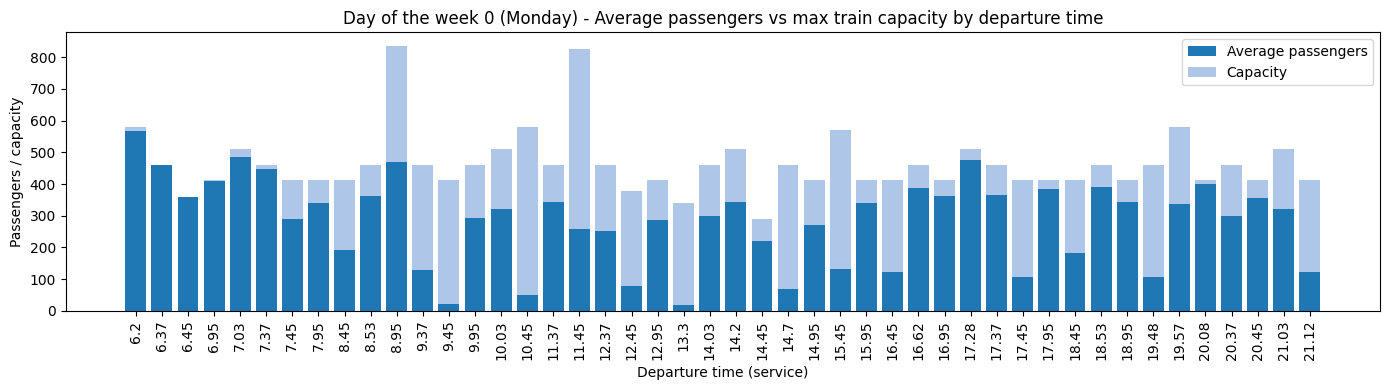

<Figure size 640x480 with 0 Axes>

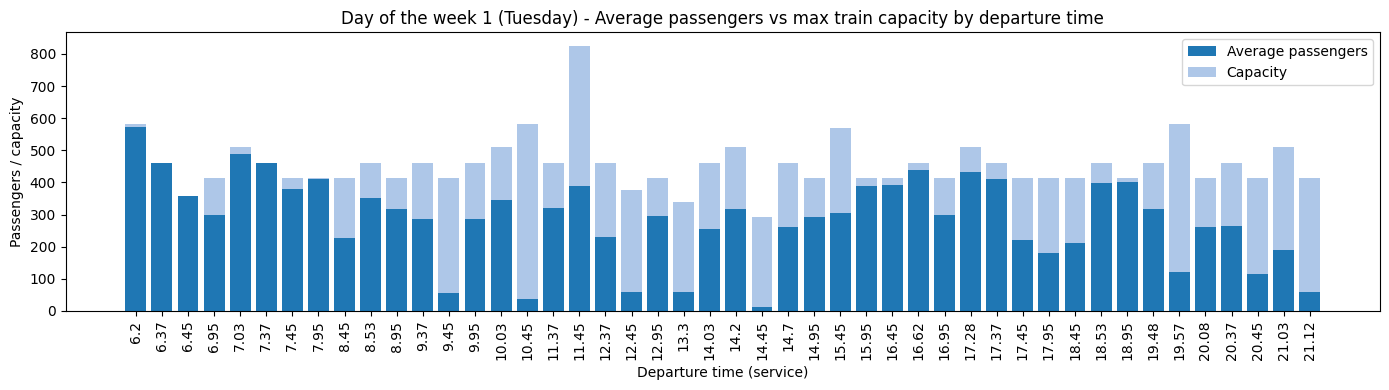

<Figure size 640x480 with 0 Axes>

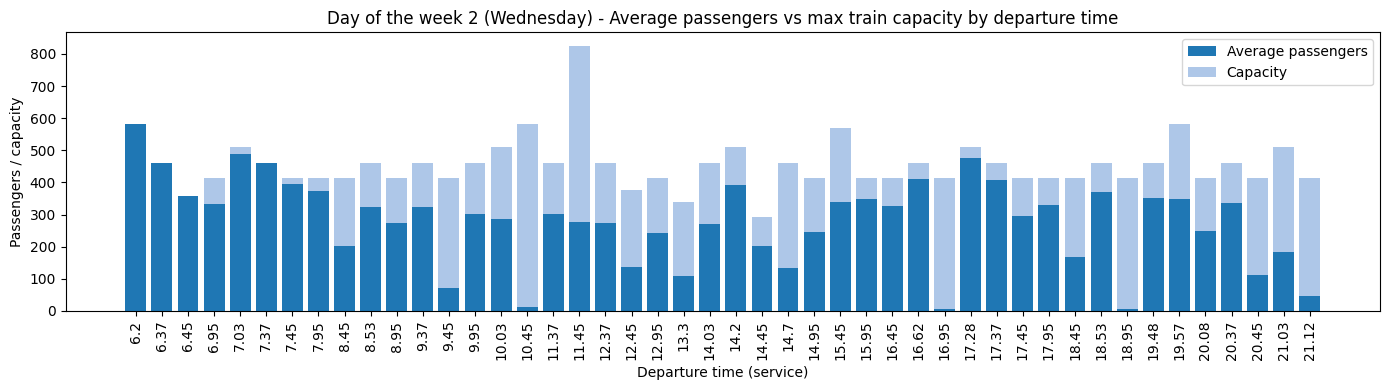

<Figure size 640x480 with 0 Axes>

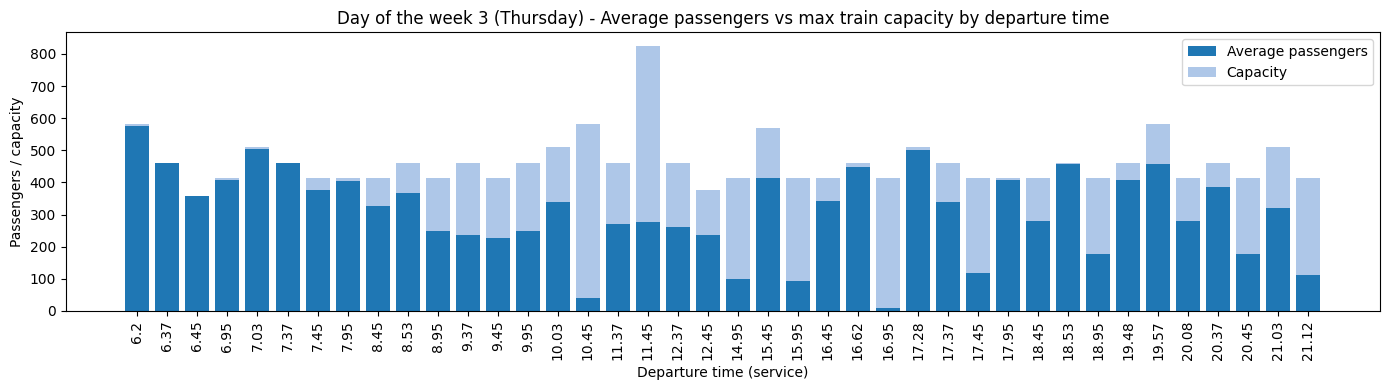

<Figure size 640x480 with 0 Axes>

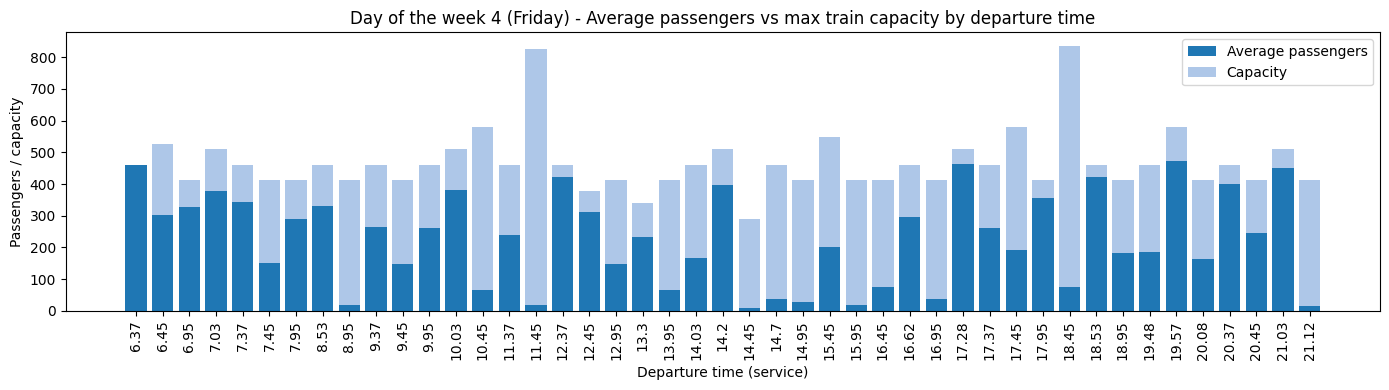

<Figure size 640x480 with 0 Axes>

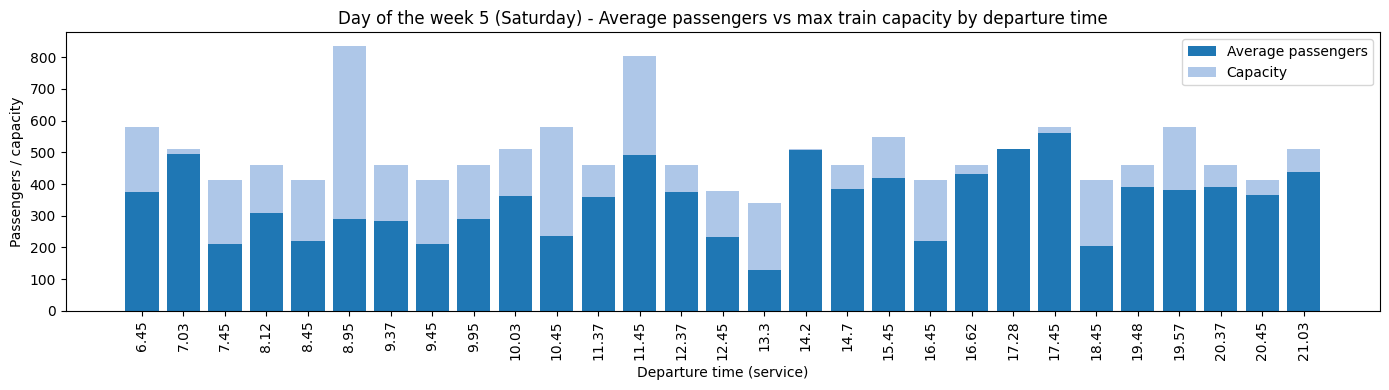

<Figure size 640x480 with 0 Axes>

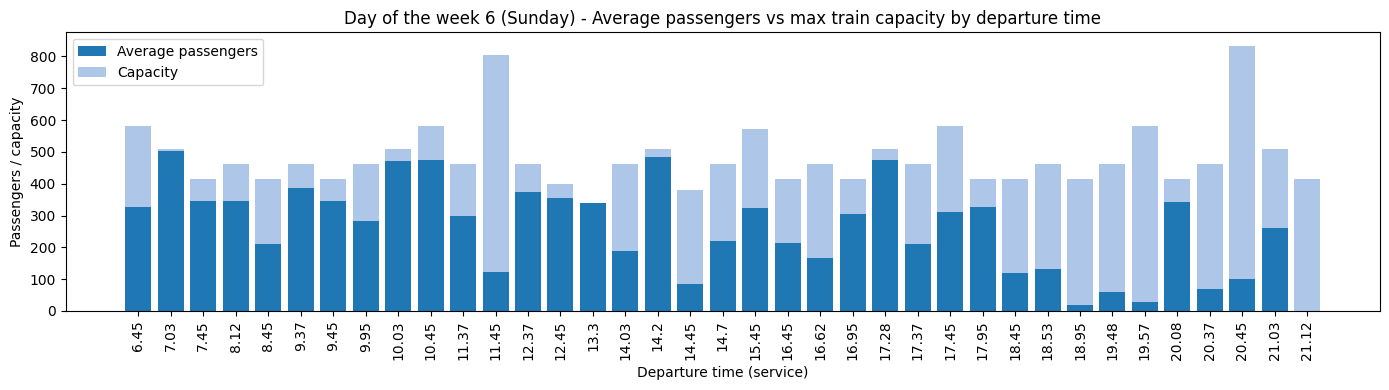

<Figure size 640x480 with 0 Axes>

In [17]:
# Which services are the most popular by day of the week and departure time?
import matplotlib.pyplot as plt

# Average passengers and max capacity by day of week and departure time
stats_day_hour = (
    final_dataset
    .groupby(['day_of_week', 'departure_time'])
    .agg(
        mean_passengers=('passengers', 'mean'),
        max_capacity=('capacity', 'max'),
    )
    .reset_index()
)

day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# One stacked bar chart for each day (0-6)
for day in range(7):
    day_data = (
        stats_day_hour[stats_day_hour['day_of_week'] == day]
        .sort_values('departure_time')
    )

    if day_data.empty:
        continue

    x = day_data['departure_time'].astype(str)
    passengers = day_data['mean_passengers']
    max_capacity = day_data['max_capacity']

    # Stacked part to reach max capacity: occupied + free capacity
    free_capacity = (max_capacity - passengers).clip(lower=0)
    overload = (passengers - max_capacity).clip(lower=0)

    plt.figure(figsize=(14, 4))
    plt.bar(x, passengers, label='Average passengers', color='#1f77b4')
    plt.bar(x, free_capacity, bottom=passengers, label='Capacity', color='#aec7e8')

    # In case any mean value exceeds max capacity (should be rare), highlight it
    if (overload > 0).any():
        plt.bar(x, overload, bottom=max_capacity, label='Over max capacity', color='#d62728')

    plt.title(
        f'Day of the week {day} ({day_names[day]}) - Average passengers vs max train capacity by departure time'
    )
    plt.xlabel('Departure time (service)')
    plt.ylabel('Passengers / capacity')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save the figure
    figure_filename = os.path.join(figures_path, f'avg_passengers_vs_capacity_day_{day}.png')
    plt.savefig(figure_filename)


In [18]:
# Print total capacity per day of the week
total_capacity_per_day = (
    final_dataset
    .groupby('day_of_week')['capacity']
    .sum()
    .reset_index()
)
total_capacity_per_day['capacity'] = total_capacity_per_day['capacity'] / 52
print("Total capacity per day of the week:")
print(total_capacity_per_day)


# Same but only the capacity of those RENFE services, ie. we have to filter the final dataset to only include the reference provider
total_capacity_per_day_ref_provider = (
    final_dataset_ref_provider[final_dataset_ref_provider['train_type'].isin(ref_provider)]
    .groupby('day_of_week')['capacity']
    .sum()
    .reset_index()
)
total_capacity_per_day_ref_provider['capacity'] = total_capacity_per_day_ref_provider['capacity'] / 52
print("Total capacity per day of the week for reference provider:")
print(total_capacity_per_day_ref_provider)

Total capacity per day of the week:
   day_of_week  capacity
0            0  21380.00
1            1  20958.00
2            2  21323.25
3            3  18483.00
4            4  21110.00
5            5  14405.00
6            6  17867.00
Total capacity per day of the week for reference provider:
   day_of_week      capacity
0            0  12381.000000
1            1  11959.000000
2            2  12154.980769
3            3  10501.000000
4            4  12111.000000
5            5   7711.000000
6            6   9790.000000
